<a href="https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/CNN_mnist_tf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import models, datasets, layers
import time
import matplotlib.pyplot as plt

## Get Dataset - MNIST

In [ ]:
mnist = datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(train_images.shape, test_images.shape)

(60000, 28, 28) (10000, 28, 28)


## Define the Model

In [ ]:
model = models.Sequential(
    [
        layers.Conv2D(32, (3,3), activation = "relu", input_shape = (28,28,1)), # Conv Layer has 32 filters of (3*3)
        layers.MaxPooling2D((2,2)), # Max Pooling layer of size (2,2)
        layers.Conv2D(64, (3,3), activation = "relu"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation  = "relu"),
        layers.Conv2D(64, (3,3), activation = "relu"),
        layers.Flatten(), # Convert to a single dimension
        layers.Dense(64, activation = "relu"), # Dense Layer with 64 activation units
        layers.Dense(10, activation = "softmax") # Dense Layer with 10 output classes
    ]
)
model.summary()

## Compile the Model
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 1, 1, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,482 (380.79 KB)

 Trainable params: 97,482 (380.79 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [ ]:
## Model Fitting, Model Evaluation & Model predictions

n_epochs = 2
for epoch in range(n_epochs):
    time_start = time.time()

    # Fit the model with training images
    model.fit(train_images, train_labels, epochs = 1)
    print("Time spent on training:{}".format(time.time() - time_start))

    # Calculate the training loss & training accuracy
    train_loss, train_acc = model.evaluate(train_images, train_labels)
    # Calculate the test loss & test accuracy
    test_loss, test_acc = model.evaluate(test_images, test_labels)

    # Predict the test images
    predictions = model.predict(test_images)
    print(f"Epoch = {epoch}, Train accuracy = {train_acc}, Test Accuracy = {test_acc}")

print(predictions.shape)

model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9900 - loss: 0.0334
Time spent on training:10.364363193511963
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9944 - loss: 0.0188
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9855 - loss: 0.0553
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch = 0, Train accuracy = 0.9944166541099548, Test Accuracy = 0.9879000186920166
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9911 - loss: 0.0268
Time spent on training:6.273083925247192
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9942 - loss: 0.0186
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9847 - loss: 0.0602
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Epoch = 1, Train accuracy = 0.993316650390625, Test Accuracy = 0.9876999855041504
(10000, 10)


## Testing the results

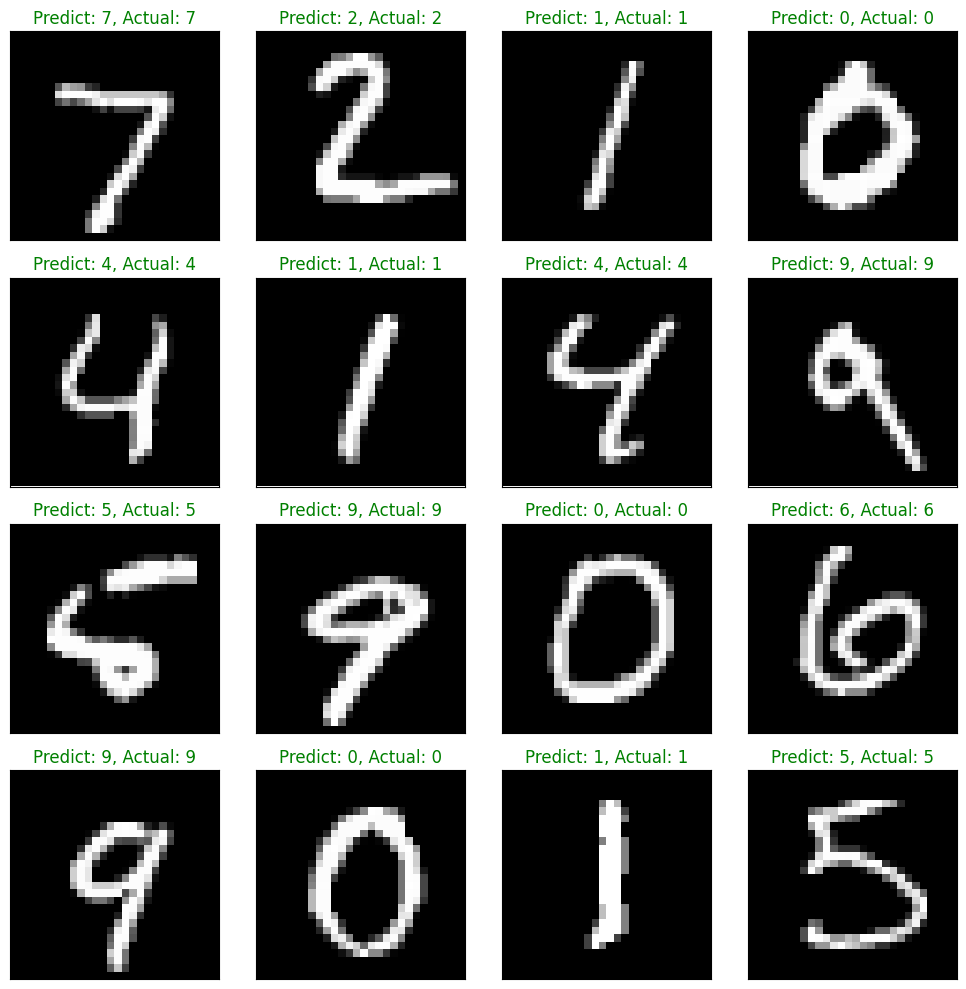

In [ ]:
## Predict and visulaize the final outputs over test images

fig = plt.figure(figsize=(10,10))
for i in range(min(16, len(test_images))):
    ax = fig.add_subplot(4, 4, i+1, xticks = [], yticks = [])
    img = test_images[i]
    ax.imshow(img, cmap='gray')
    predict_label = predictions[i].argmax()
    color = "green" if predict_label == test_labels[i] else "red"
    ax.set_title(f"Predict: {predict_label}, Actual: {test_labels[i]}", color=color)

plt.tight_layout()
plt.show()